# Pima Indians Diabetes — Exploratory Analysis & Model Training

**Goal:** Predict whether a patient has diabetes based on diagnostic
measurements from the Pima Indians Diabetes dataset (768 records, 8
features + binary Outcome).

This notebook covers:
1. Loading & cleaning the data
2. Exploratory Data Analysis (EDA)
3. Preprocessing (missing-value imputation, scaling, train/test split)
4. Training and comparing Logistic Regression, SVM, and Random Forest
5. Evaluating the best model (confusion matrix, classification report, ROC-AUC)
6. Saving the trained model for later use in `prediction.py`


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
)

sns.set_style("whitegrid")
%matplotlib inline


## 1. Load the data

In [2]:
df = pd.read_csv("../data/dataset.csv")
print(df.shape)
df.head()


(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## 2. Exploratory Data Analysis

Note: several columns (`Glucose`, `BloodPressure`, `SkinThickness`,
`Insulin`, `BMI`) use `0` to represent a missing measurement — that is
not physiologically possible, so we treat those zeros as missing
values during cleaning.

In [5]:
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
missing_counts = (df[zero_cols] == 0).sum()
missing_counts


Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

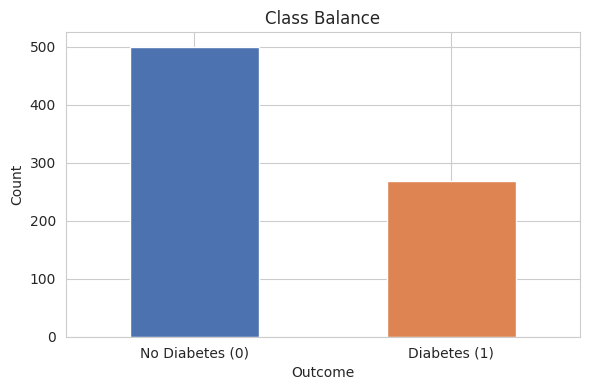

In [6]:
plt.figure(figsize=(6, 4))
df["Outcome"].value_counts().plot(kind="bar", color=["#4C72B0", "#DD8452"])
plt.xticks([0, 1], ["No Diabetes (0)", "Diabetes (1)"], rotation=0)
plt.ylabel("Count")
plt.title("Class Balance")
plt.tight_layout()
plt.show()


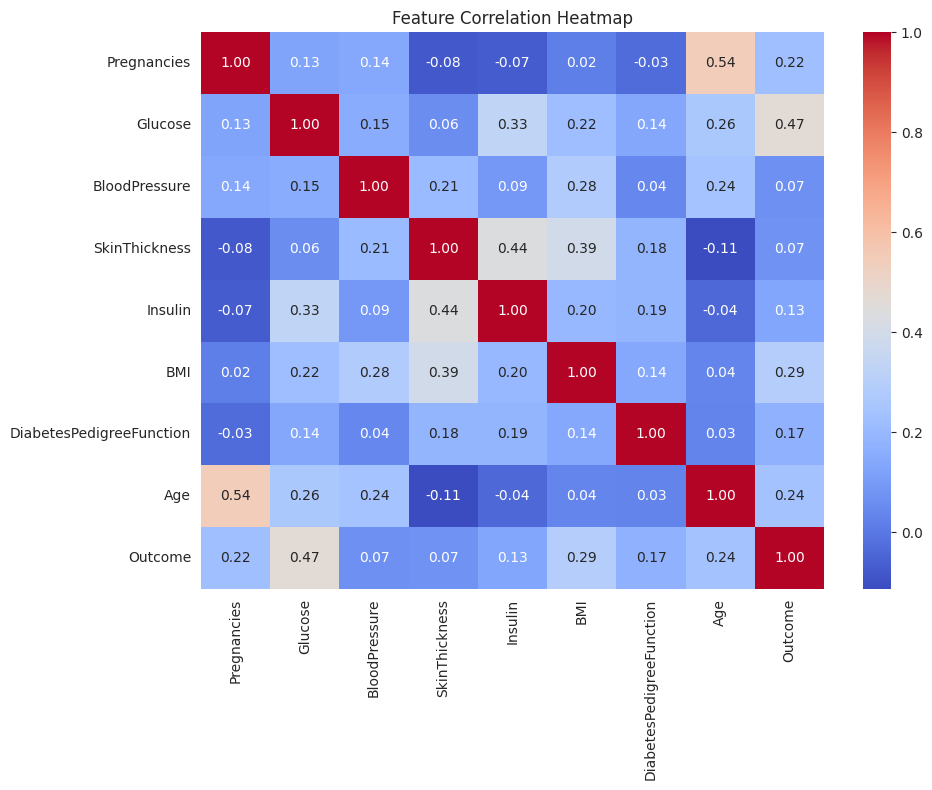

In [7]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


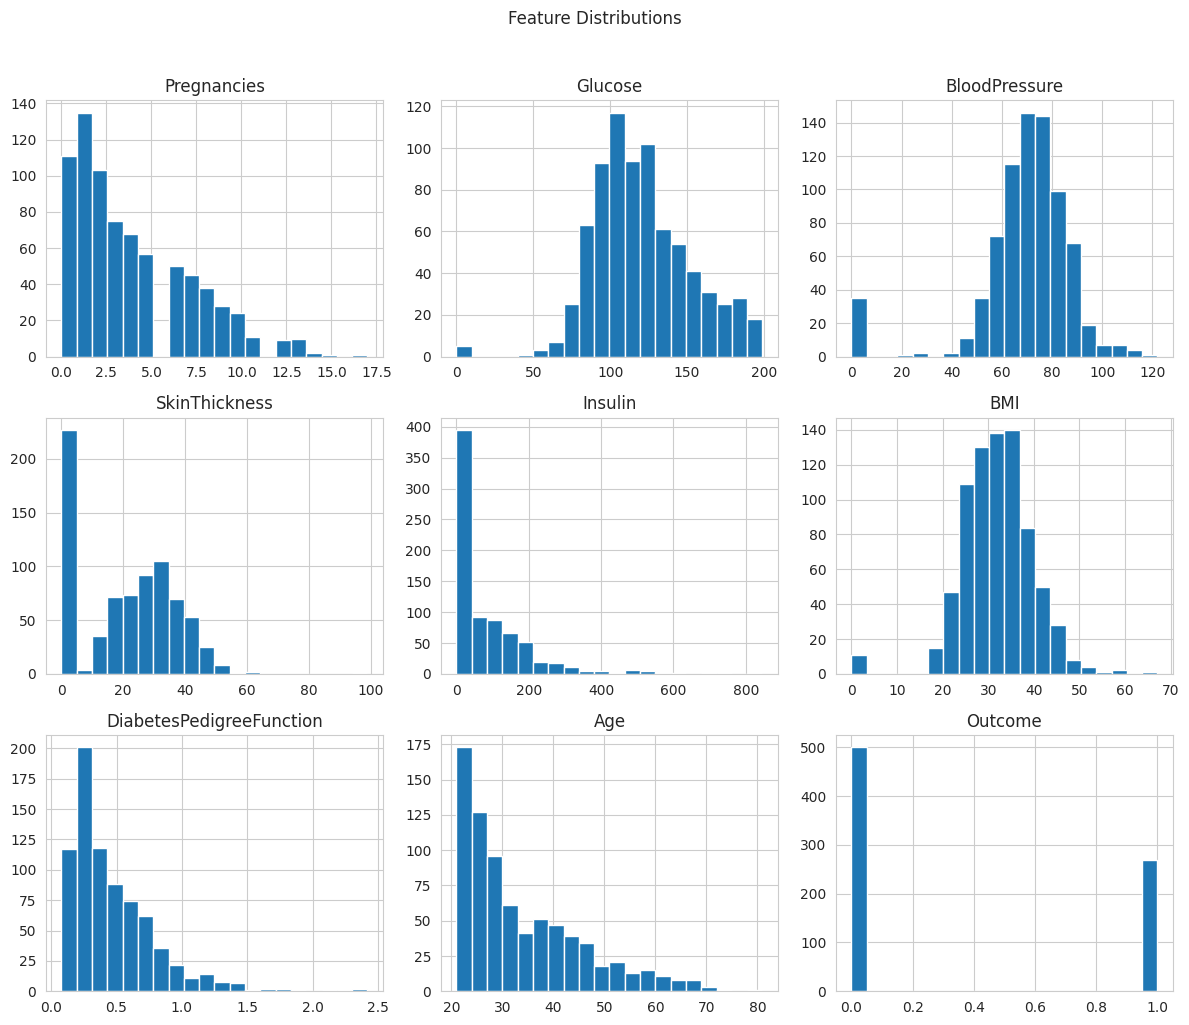

In [8]:
df.hist(figsize=(12, 10), bins=20)
plt.suptitle("Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()


## 3. Cleaning & Preprocessing

In [9]:
df_clean = df.copy()
for col in zero_cols:
    df_clean[col] = df_clean[col].replace(0, np.nan)
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

df_clean[zero_cols].describe()


,Glucose,BloodPressure,SkinThickness,Insulin,BMI
count,768.000000,768.000000,768.000000,768.000000,768.000000
mean,121.656250,72.386719,29.108073,140.671875,32.455208
std,30.438286,12.096642,8.791221,86.383060,6.875177
min,44.000000,24.000000,7.000000,14.000000,18.200000
25%,99.750000,64.000000,25.000000,121.500000,27.500000
50%,117.000000,72.000000,29.000000,125.000000,32.300000
75%,140.250000,80.000000,32.000000,127.250000,36.600000
max,199.000000,122.000000,99.000000,846.000000,67.100000


In [10]:
X = df_clean.drop(columns=["Outcome"])
y = df_clean["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape: ", X_test_scaled.shape)


Train shape: (614, 8)
Test shape:  (154, 8)


## 4. Train & Compare Models

In [11]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Support Vector Machine": SVC(probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    results[name] = {"model": model, "accuracy": acc}
    print(f"{name:25s} accuracy = {acc:.4f}")


Logistic Regression       accuracy = 0.7078
Support Vector Machine    accuracy = 0.7403


Random Forest             accuracy = 0.7338


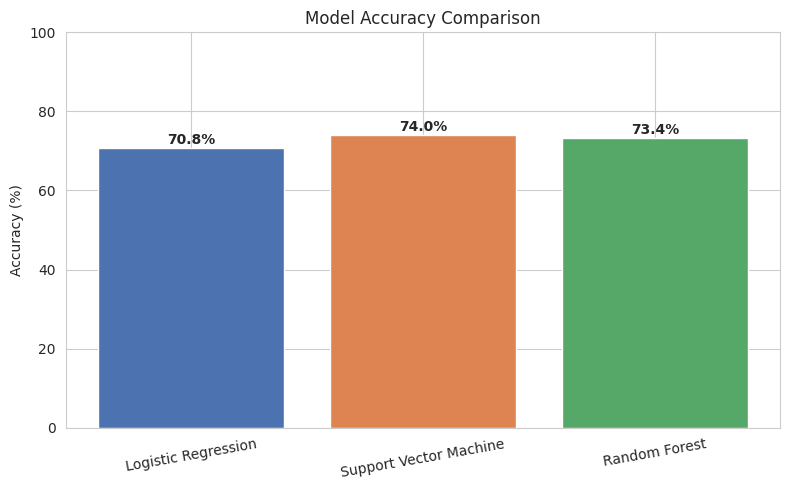

In [12]:
names = list(results.keys())
accs = [results[n]["accuracy"] * 100 for n in names]

plt.figure(figsize=(8, 5))
bars = plt.bar(names, accs, color=["#4C72B0", "#DD8452", "#55A868"])
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 100)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{acc:.1f}%",
             ha="center", fontweight="bold")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()


## 5. Evaluate the Best Model

In [13]:
best_name = max(results, key=lambda n: results[n]["accuracy"])
best_model = results[best_name]["model"]
print("Best model:", best_name)

y_pred = best_model.predict(X_test_scaled)
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


Best model: Support Vector Machine
              precision    recall  f1-score   support

           0       0.78      0.84      0.81       100
           1       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154

ROC-AUC: 0.7963888888888889


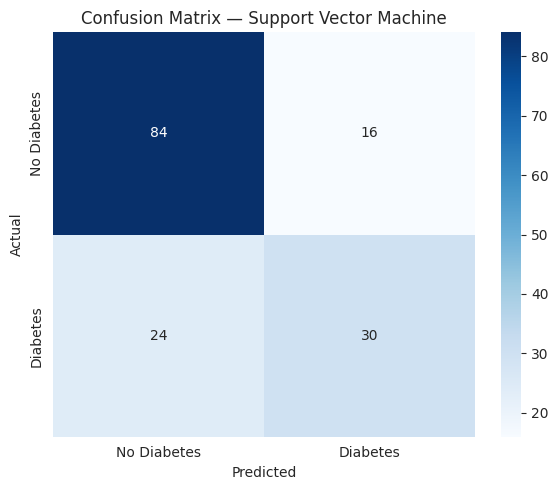

In [14]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Diabetes", "Diabetes"],
            yticklabels=["No Diabetes", "Diabetes"])
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title(f"Confusion Matrix — {best_name}")
plt.tight_layout()
plt.show()


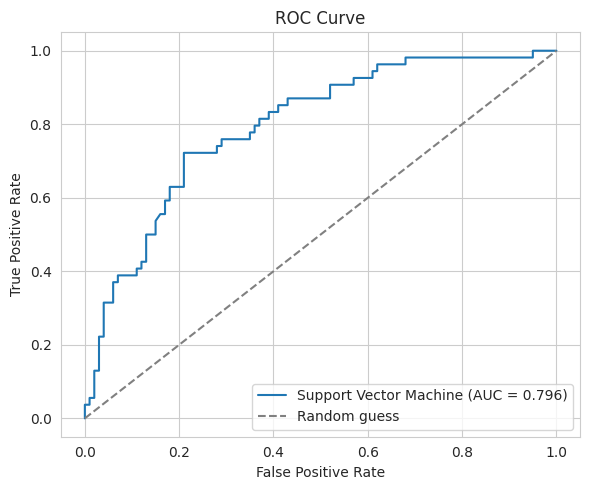

In [15]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"{best_name} (AUC = {roc_auc_score(y_test, y_proba):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()


## 6. Save the Trained Model

In [16]:
import pickle, os

os.makedirs("../outputs", exist_ok=True)
artifact = {
    "model": best_model,
    "scaler": scaler,
    "feature_names": list(X.columns),
    "model_name": best_name,
    "test_accuracy": results[best_name]["accuracy"],
}
with open("../outputs/trained_model.pkl", "wb") as f:
    pickle.dump(artifact, f)

print("Model saved to ../outputs/trained_model.pkl")


Model saved to ../outputs/trained_model.pkl


## Conclusion

- The dataset's implausible zero values were treated as missing and
  imputed with the column median.
- Three models were compared; the best performing model was selected
  based on test-set accuracy.
- The final model, along with the fitted scaler, was saved so it can
  be reused directly for predictions on new patients via
  `src/prediction.py`.
